## Scikit-learn Pipeline House Price Prediction

This notebook revises the complete supervised machine learning workflow using
a Random Forest Regression model and a Scikit-learn preprocessing pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 12.2 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.1 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- --------------

In [3]:
df = pd.read_csv("bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [4]:
df.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(1049)

### Selecting features and target

In [6]:
features = ["location", "total_sqft", "bath", "bhk"]

X = df[features]
y = df["price"]

In [7]:
X.head()

,location,total_sqft,bath,bhk
0,Electronic City Phase II,1056.0,2.0,2
1,Chikka Tirupathi,2600.0,5.0,4
2,Uttarahalli,1440.0,2.0,3
3,Lingadheeranahalli,1521.0,3.0,3
4,Kothanur,1200.0,2.0,2


In [8]:
y.head()

0     39.07
1    120.00
2     62.00
3     95.00
4     51.00
Name: price, dtype: float64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
numeric_features = ["total_sqft", "bath", "bhk"]
categorical_features = ["location"]

### Numerical preprocessing

In [11]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Categorical preprocessing

In [12]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [13]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

### Randome forest model

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [15]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

In [17]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['location','total_sqft','bath','bhk']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of 

### Predictions

In [18]:
y_pred = pipeline.predict(X_test)

In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,80.0,87.792729
1,75.0,509.511667
2,61.0,65.539130
3,62.0,56.979459
4,56.5,57.155592
5,27.0,14.023389
6,58.0,52.520982
7,62.0,76.184900
8,75.0,86.948717
9,99.0,113.308000


### Evaluation

In [20]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 33.54534843661897


In [21]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 89.02963613095022


### Visualisation (actual vs predicted)

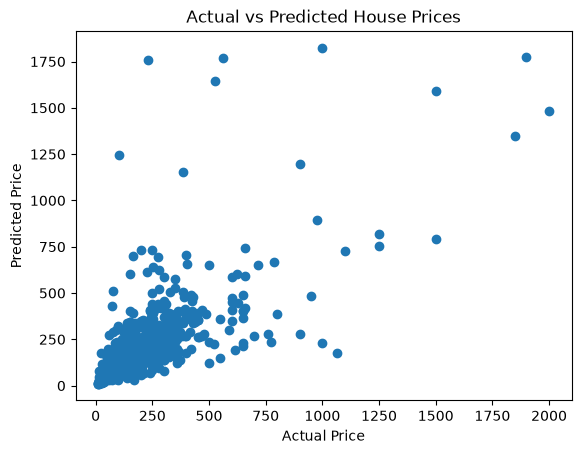

In [22]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

### New prediction

In [23]:
new_house = pd.DataFrame({
    "location": ["Whitefield"],
    "total_sqft": [1200],
    "bath": [2],
    "bhk": [2]
})

In [24]:
predicted_price = pipeline.predict(new_house)
print("Predicted price:", predicted_price[0])

Predicted price: 48.914248168498155


### Summary

This notebook demonstrated an end-to-end supervised machine learning workflow:

1. Loaded and inspected the dataset
2. Selected features and target
3. Split data into training and testing sets
4. Identified numerical and categorical features
5. Created preprocessing pipelines
6. Used ColumnTransformer to combine preprocessing
7. Built a RandomForestRegressor
8. Combined preprocessing and the model into a Pipeline
9. Trained the pipeline
10. Generated predictions
11. Evaluated the model using MAE, RMSE
12. Used the pipeline to predict a new house price

The Pipeline ensures that preprocessing and model training are performed
consistently and helps prevent data leakage.